In [41]:
import rasterio
import geopandas
import pystac_client
import planetary_computer
import shapely
import pyproj
import requests
import matplotlib
import geopandas as gpd
from shapely.geometry import Polygon


print("All libraries loaded successfully")


All libraries loaded successfully


In [3]:
import os
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.mask import mask
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Polygon


In [43]:
os.makedirs("data/pre2025", exist_ok=True)
os.makedirs("data/post2025", exist_ok=True)
os.makedirs("data/results", exist_ok=True)


In [44]:
import pystac_client
from datetime import datetime
import geopandas as gpd
from shapely.geometry import Polygon
from rasterio.merge import merge




In [71]:
#Connect to Sentinel-2 STAC
catalog = pystac_client.Client.open("https://earth-search.aws.element84.com/v1")


In [72]:
#Search Pre & Post Monsoon 2025
pre_search = catalog.search(
    collections=["sentinel-2-l2a"],
    intersects=aoi.geometry[0].__geo_interface__,
    datetime="2025-05-01/2025-05-31",
    query={"eo:cloud_cover": {"lt": 20}}
)

pre_items = list(pre_search.get_items())
print("Pre-monsoon scenes:", len(pre_items))


C:\Users\Lenovo\.conda\envs\gis\lib\site-packages\pystac_client\item_search.py:925: FutureWarning: get_items() is deprecated, use items() instead
  warnings.warn(


Pre-monsoon scenes: 47


In [73]:
#Search Pre & Post Monsoon 2025
post_search = catalog.search(
    collections=["sentinel-2-l2a"],
    intersects=aoi.geometry[0].__geo_interface__,
    datetime="2025-09-01/2025-09-30",
    query={"eo:cloud_cover": {"lt": 20}}
)

post_items = list(post_search.get_items())
print("Post-monsoon scenes:", len(post_items))


Post-monsoon scenes: 17


In [49]:
[item.id for item in post_items]


['S2B_42RZP_20250926_0_L2A',
 'S2B_43RBJ_20250926_0_L2A',
 'S2B_43RBK_20250926_0_L2A',
 'S2A_42RZP_20250923_1_L2A',
 'S2A_43RBK_20250923_1_L2A',
 'S2B_42RZP_20250923_0_L2A',
 'S2B_43RCJ_20250923_0_L2A',
 'S2B_43RBK_20250923_0_L2A',
 'S2C_43RBK_20250921_0_L2A',
 'S2C_43RBK_20250918_0_L2A',
 'S2C_43RCK_20250918_0_L2A',
 'S2B_43RBJ_20250913_0_L2A',
 'S2B_43RBK_20250913_0_L2A',
 'S2A_42RZP_20250903_1_L2A',
 'S2A_43RBJ_20250903_1_L2A',
 'S2A_43RBK_20250903_1_L2A',
 'S2B_43RBK_20250903_0_L2A']

In [74]:
#AOI (Jojari River)
aoi_coords = [
    (72.6817, 26.4397),
    (73.5056, 26.4717),
    (73.4864, 26.0506),
    (72.6681, 26.0678)
]

aoi = gpd.GeoDataFrame(
    geometry=[Polygon(aoi_coords)],
    crs="EPSG:4326"
)


In [75]:
#Keep 1 Best Scene Per Tile
def best_per_tile(items):
    best = {}
    for item in items:
        tile = item.properties.get("mgrs:tile")   # ✅ correct key
        cloud = item.properties.get("eo:cloud_cover", 100)

        if tile is None:
            tile = item.id  # fallback, should not happen often

        if tile not in best or cloud < best[tile].properties.get("eo:cloud_cover", 100):
            best[tile] = item

    return list(best.values())


In [76]:
#Download Bands
pre_best  = best_per_tile(pre_items)
post_best = best_per_tile(post_items)

print("Pre tiles:", len(pre_best))
print("Post tiles:", len(post_best))


Pre tiles: 47
Post tiles: 17


In [53]:
print(pre_best[0].assets.keys())


dict_keys(['aot', 'blue', 'cloud', 'coastal', 'granule_metadata', 'green', 'nir', 'nir08', 'nir09', 'product_metadata', 'red', 'rededge1', 'rededge2', 'rededge3', 'scl', 'snow', 'swir16', 'swir22', 'tileinfo_metadata', 'visual', 'wvp', 'thumbnail', 'aot-jp2', 'blue-jp2', 'coastal-jp2', 'green-jp2', 'nir-jp2', 'nir08-jp2', 'nir09-jp2', 'red-jp2', 'rededge1-jp2', 'rededge2-jp2', 'rededge3-jp2', 'scl-jp2', 'swir16-jp2', 'swir22-jp2', 'visual-jp2', 'wvp-jp2'])


In [77]:
# Image Downloader
from planetary_computer import sign

def download_bands(items, folder):
    os.makedirs(folder, exist_ok=True)
    paths = []

    for item in items:
        signed_item = sign(item)   # ✅ SIGN HERE

        for band in ["red", "nir","green"]:
            asset = signed_item.assets.get(band)
            if asset is None:
                print(f"⚠ Missing {band} for {item.id}")
                continue

            url = asset.href
            out = f"{folder}/{item.id}_{band}.tif"

            if not os.path.exists(out):
                print("⬇ Downloading", band, "from", item.id)
                with requests.get(url, stream=True) as r:
                    r.raise_for_status()
                    with open(out, "wb") as f:
                        for chunk in r.iter_content(chunk_size=1024*1024):
                            if chunk:
                                f.write(chunk)
                print("✅ Done")

            paths.append(out)

    return paths


In [78]:
pre_paths  = download_bands(pre_best,  "data/pre2025")
post_paths = download_bands(post_best, "data/post2025")


⬇ Downloading green from S2C_42RZP_20250531_0_L2A
✅ Done
⬇ Downloading green from S2C_43RBJ_20250531_0_L2A
✅ Done
⬇ Downloading green from S2C_43RCJ_20250531_0_L2A
✅ Done
⬇ Downloading green from S2C_43RBK_20250531_0_L2A
✅ Done
⬇ Downloading green from S2C_43RCK_20250531_0_L2A
✅ Done
⬇ Downloading green from S2B_43RBK_20250529_0_L2A
✅ Done
⬇ Downloading green from S2A_42RZP_20250526_1_L2A
✅ Done
⬇ Downloading green from S2A_43RBJ_20250526_1_L2A
✅ Done
⬇ Downloading green from S2A_43RBK_20250526_2_L2A
✅ Done
⬇ Downloading green from S2B_42RZP_20250526_0_L2A
✅ Done
⬇ Downloading green from S2B_43RBJ_20250526_0_L2A
✅ Done
⬇ Downloading green from S2B_43RCJ_20250526_0_L2A
✅ Done
⬇ Downloading green from S2B_43RBK_20250526_1_L2A
✅ Done
⬇ Downloading green from S2B_43RCK_20250526_0_L2A
✅ Done
⬇ Downloading green from S2C_42RZP_20250524_0_L2A
✅ Done
⬇ Downloading green from S2C_43RBJ_20250524_0_L2A
✅ Done
⬇ Downloading green from S2C_43RBK_20250524_0_L2A
✅ Done
⬇ Downloading green from S2C_42

In [79]:
#Find Corrupted Files
import rasterio
import os

def find_bad_tiffs(folder):
    bad = []
    for f in os.listdir(folder):
        if f.endswith(".tif"):
            path = os.path.join(folder, f)
            try:
                with rasterio.open(path) as ds:
                    ds.read(1)
            except Exception as e:
                bad.append(path)
                print("❌ Corrupt:", path)
    return bad

bad_pre = find_bad_tiffs("data/pre2025")
bad_post = find_bad_tiffs("data/post2025")

print("Bad pre:", bad_pre)
print("Bad post:", bad_post)


Bad pre: []
Bad post: []


In [57]:
#Delete broken files
for f in bad_pre + bad_post:
    os.remove(f)
    print("🗑 Deleted", f)


In [41]:
#Re-download the missing files
import requests
import os

def safe_download(url, out_path):
    r = requests.get(url, stream=True, timeout=60)
    r.raise_for_status()

    with open(out_path, "wb") as f:
        for chunk in r.iter_content(chunk_size=1024*1024):
            if chunk:
                f.write(chunk)

    # Quick integrity check
    with rasterio.open(out_path) as ds:
        ds.read(1)

def download_bands_safe(items, folder):
    os.makedirs(folder, exist_ok=True)
    paths = []

    for item in items:
        for band, name in [("red", "red"), ("nir", "nir")]:
            asset = item.assets.get(band)
            if asset is None:
                print("⚠ Missing band for", item.id)
                continue

            out = f"{folder}/{item.id}_{name}.tif"
            if os.path.exists(out):
                paths.append(out)
                continue

            print("⬇ Downloading", out)
            try:
                safe_download(asset.href, out)
                paths.append(out)
                print("✅ OK", out)
            except Exception as e:
                print("❌ Failed:", out, e)
                if os.path.exists(out):
                    os.remove(out)

    return paths


In [32]:
pre_paths  = download_bands_safe(pre_best,  "data/pre2025")
post_paths = download_bands_safe(post_best, "data/post2025")


NameError: name 'download_bands_safe' is not defined

In [82]:
from rasterio.warp import calculate_default_transform, reproject, Resampling
import rasterio
import os

def reproject_to_3857(in_path, out_path):
    try:
        with rasterio.open(in_path) as src:
            transform, width, height = calculate_default_transform(
                src.crs, "EPSG:3857", src.width, src.height, *src.bounds
            )
            meta = src.meta.copy()
            meta.update({
                "crs": "EPSG:3857",
                "transform": transform,
                "width": width,
                "height": height
            })

            with rasterio.open(out_path, "w", **meta) as dst:
                reproject(
                    source=rasterio.band(src, 1),
                    destination=rasterio.band(dst, 1),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs="EPSG:3857",
                    resampling=Resampling.bilinear
                )
        return out_path
    except Exception as e:
        print("❌ Failed to reproject:", in_path)
        print("   Reason:", e)
        return None


In [83]:
pre_red_3857   = []
pre_nir_3857   = []
pre_green_3857 = []

for p in pre_paths:
    if p.endswith("_red.tif"):
        out = p.replace(".tif", "_3857.tif")
        r = reproject_to_3857(p, out)
        if r: pre_red_3857.append(r)

    if p.endswith("_nir.tif"):
        out = p.replace(".tif", "_3857.tif")
        r = reproject_to_3857(p, out)
        if r: pre_nir_3857.append(r)

    if p.endswith("_green.tif"):   # ✅ NEW
        out = p.replace(".tif", "_3857.tif")
        r = reproject_to_3857(p, out)
        if r: pre_green_3857.append(r)

print("Pre red:", len(pre_red_3857))
print("Pre nir:", len(pre_nir_3857))
print("Pre green:", len(pre_green_3857))


Pre red: 47
Pre nir: 47
Pre green: 47


In [84]:
post_red_3857   = []
post_nir_3857   = []
post_green_3857 = []

for p in post_paths:
    if p.endswith("_red.tif"):
        out = p.replace(".tif", "_3857.tif")
        r = reproject_to_3857(p, out)
        if r: post_red_3857.append(r)

    if p.endswith("_nir.tif"):
        out = p.replace(".tif", "_3857.tif")
        r = reproject_to_3857(p, out)
        if r: post_nir_3857.append(r)

    if p.endswith("_green.tif"):   # ✅ NEW
        out = p.replace(".tif", "_3857.tif")
        r = reproject_to_3857(p, out)
        if r: post_green_3857.append(r)

print("Post red:", len(post_red_3857))
print("Post nir:", len(post_nir_3857))
print("Post green:", len(post_green_3857))


Post red: 17
Post nir: 17
Post green: 17


In [85]:
#check crs of reprojected files
import rasterio
import os

def check_crs(folder):
    for f in os.listdir(folder):
        if f.endswith("_3857.tif"):
            path = os.path.join(folder, f)
            with rasterio.open(path) as ds:
                print(f, "→ CRS:", ds.crs)

check_crs("data/pre2025")
check_crs("data/post2025")


S2A_42RZP_20250513_0_L2A_green_3857.tif → CRS: EPSG:3857
S2A_42RZP_20250513_0_L2A_nir_3857.tif → CRS: EPSG:3857
S2A_42RZP_20250513_0_L2A_red_3857.tif → CRS: EPSG:3857
S2A_42RZP_20250526_1_L2A_green_3857.tif → CRS: EPSG:3857
S2A_42RZP_20250526_1_L2A_nir_3857.tif → CRS: EPSG:3857
S2A_42RZP_20250526_1_L2A_red_3857.tif → CRS: EPSG:3857
S2A_43RBJ_20250513_0_L2A_green_3857.tif → CRS: EPSG:3857
S2A_43RBJ_20250513_0_L2A_nir_3857.tif → CRS: EPSG:3857
S2A_43RBJ_20250513_0_L2A_red_3857.tif → CRS: EPSG:3857
S2A_43RBJ_20250526_1_L2A_green_3857.tif → CRS: EPSG:3857
S2A_43RBJ_20250526_1_L2A_nir_3857.tif → CRS: EPSG:3857
S2A_43RBJ_20250526_1_L2A_red_3857.tif → CRS: EPSG:3857
S2A_43RBK_20250513_0_L2A_green_3857.tif → CRS: EPSG:3857
S2A_43RBK_20250513_0_L2A_nir_3857.tif → CRS: EPSG:3857
S2A_43RBK_20250513_0_L2A_red_3857.tif → CRS: EPSG:3857
S2A_43RBK_20250526_2_L2A_green_3857.tif → CRS: EPSG:3857
S2A_43RBK_20250526_2_L2A_nir_3857.tif → CRS: EPSG:3857
S2A_43RBK_20250526_2_L2A_red_3857.tif → CRS: EPSG:385

In [86]:
#check if all the files got reprojected
pre_orig = [f for f in os.listdir("data/pre2025") if f.endswith(".tif") and not f.endswith("_3857.tif")]
pre_3857 = [f for f in os.listdir("data/pre2025") if f.endswith("_3857.tif")]

post_orig = [f for f in os.listdir("data/post2025") if f.endswith(".tif") and not f.endswith("_3857.tif")]
post_3857 = [f for f in os.listdir("data/post2025") if f.endswith("_3857.tif")]

print("Pre original:", len(pre_orig))
print("Pre reprojected:", len(pre_3857))

print("Post original:", len(post_orig))
print("Post reprojected:", len(post_3857))


Pre original: 141
Pre reprojected: 141
Post original: 51
Post reprojected: 51


In [87]:
#remove the corrupted reprojected files
bad = []

for folder in ["data/pre2025", "data/post2025"]:
    for f in os.listdir(folder):
        if f.endswith("_3857.tif"):
            path = os.path.join(folder, f)
            try:
                with rasterio.open(path) as ds:
                    ds.read(1)
            except Exception as e:
                bad.append(path)
                print("❌ Broken:", path, e)

print("Total broken reprojected files:", len(bad))


Total broken reprojected files: 0


In [88]:
#Reprojected files
import glob

files = glob.glob("data/pre2025/*_3857.tif") + glob.glob("data/post2025/*_3857.tif")

print("Total reprojected files found:", len(files))
files[:5]


Total reprojected files found: 192


['data/pre2025\\S2A_42RZP_20250513_0_L2A_green_3857.tif',
 'data/pre2025\\S2A_42RZP_20250513_0_L2A_nir_3857.tif',
 'data/pre2025\\S2A_42RZP_20250513_0_L2A_red_3857.tif',
 'data/pre2025\\S2A_42RZP_20250526_1_L2A_green_3857.tif',
 'data/pre2025\\S2A_42RZP_20250526_1_L2A_nir_3857.tif']

In [90]:
import geopandas as gpd
from shapely.geometry import Polygon
#aoi for study area
aoi_coords = [
    (72.6817, 26.4397),   # Lon, Lat (Banar side)
    (73.5056, 26.4717),
    (73.4864, 26.0506),  # Salawas side
    (72.6681, 26.0678)
]

aoi = gpd.GeoDataFrame(geometry=[Polygon(aoi_coords)], crs="EPSG:4326")
aoi_3857 = aoi.to_crs("EPSG:3857")


In [91]:
#overlap function
import rasterio
from rasterio.mask import mask

def overlaps_aoi(raster_path, aoi_gdf):
    try:
        with rasterio.open(raster_path) as src:
            mask(src, aoi_gdf.geometry, crop=True)
        return True
    except:
        return False


In [61]:
#files overlapping the aoi
from rasterio.mask import mask

def overlaps_aoi(raster_path, aoi):
    try:
        with rasterio.open(raster_path) as src:
            mask(src, aoi.geometry, crop=True)
        return True
    except:
        return False

pre_red_3857 = [f for f in files if "pre2025" in f and "_red_3857.tif" in f and overlaps_aoi(f, aoi_3857)]
post_red_3857 = [f for f in files if "post2025" in f and "_red_3857.tif" in f and overlaps_aoi(f, aoi_3857)]

print("Valid pre tiles:", len(pre_red_3857))
print("Valid post tiles:", len(post_red_3857))


Valid pre tiles: 47
Valid post tiles: 17


In [92]:
from rasterio.merge import merge
import rasterio
import os

def mosaic(paths, out_path):
    srcs = [rasterio.open(p) for p in paths]
    mosaic_arr, transform = merge(srcs)
    meta = srcs[0].meta.copy()
    meta.update({
        "height": mosaic_arr.shape[1],
        "width": mosaic_arr.shape[2],
        "transform": transform
    })
    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(mosaic_arr)
    for s in srcs:
        s.close()

# Pre-monsoon mosaics
mosaic(pre_red_3857,   "data/results/pre_red_3857.tif")
mosaic(pre_nir_3857,   "data/results/pre_nir_3857.tif")
mosaic(pre_green_3857, "data/results/pre_green_3857.tif")   # ✅ Green

# Post-monsoon mosaics
mosaic(post_red_3857,   "data/results/post_red_3857.tif")
mosaic(post_nir_3857,   "data/results/post_nir_3857.tif")
mosaic(post_green_3857, "data/results/post_green_3857.tif") # ✅ Green


In [63]:
#mosaic
from rasterio.merge import merge
import os

def mosaic(paths, out_path):
    srcs = [rasterio.open(p) for p in paths]
    mosaic_arr, transform = merge(srcs)
    meta = srcs[0].meta.copy()
    meta.update({
        "height": mosaic_arr.shape[1],
        "width": mosaic_arr.shape[2],
        "transform": transform
    })
    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(mosaic_arr)
    for s in srcs:
        s.close()

mosaic(pre_red_3857,  "data/results/pre_red_3857.tif")
mosaic(pre_nir_3857,  "data/results/pre_nir_3857.tif")
mosaic(post_red_3857, "data/results/post_red_3857.tif")
mosaic(post_nir_3857, "data/results/post_nir_3857.tif")


In [64]:
#Calculate Pre and Post NDVI
import numpy as np

def ndvi(red_path, nir_path, out_path):
    with rasterio.open(red_path) as r, rasterio.open(nir_path) as n:
        red = r.read(1).astype("float32")
        nir = n.read(1).astype("float32")
        ndvi = (nir - red) / (nir + red + 1e-6)

        meta = r.meta.copy()
        meta.update(dtype="float32", nodata=np.nan)

        with rasterio.open(out_path, "w", **meta) as dst:
            dst.write(ndvi, 1)

ndvi("data/results/pre_red_3857.tif",  "data/results/pre_nir_3857.tif",  "data/results/pre_ndvi_3857.tif")
ndvi("data/results/post_red_3857.tif", "data/results/post_nir_3857.tif", "data/results/post_ndvi_3857.tif")


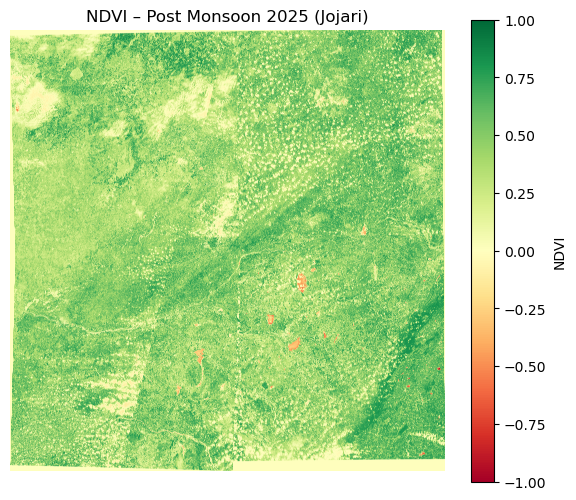

In [65]:
import matplotlib.pyplot as plt

with rasterio.open("data/results/post_ndvi_3857.tif") as src:
    plt.figure(figsize=(7,6))
    plt.imshow(src.read(1), cmap="RdYlGn", vmin=-1, vmax=1)
    plt.colorbar(label="NDVI")
    plt.title("NDVI – Post Monsoon 2025 (Jojari)")
    plt.axis("off")
    plt.show()


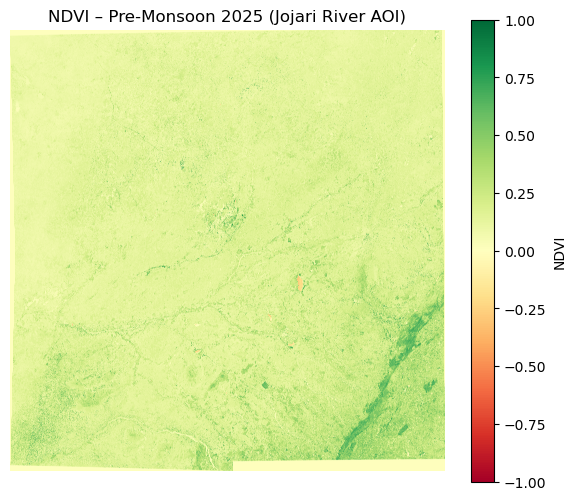

In [66]:
import matplotlib.pyplot as plt
import rasterio

with rasterio.open("data/results/pre_ndvi_3857.tif") as src:
    plt.figure(figsize=(7,6))
    plt.imshow(src.read(1), cmap="RdYlGn", vmin=-1, vmax=1)
    plt.colorbar(label="NDVI")
    plt.title("NDVI – Pre-Monsoon 2025 (Jojari River AOI)")
    plt.axis("off")
    plt.show()


In [67]:
#aoi for study area clip
aoi_coords = [
    (72.6811, 26.4397),  # 26°26'23"N, 72°40'54"E
    (73.5056, 26.4717),  # 26°28'18"N, 73°30'20"E
    (73.4864, 26.0506),  # 26°03'02"N, 73°29'11"E
    (72.6681, 26.0678)   # 26°04'04"N, 72°40'05"E
]

aoi = gpd.GeoDataFrame(geometry=[Polygon(aoi_coords)], crs="EPSG:4326")


In [68]:
#reproject aoi
aoi_3857 = aoi.to_crs("EPSG:3857")


In [69]:
#clip study area using aio
def clip_ndvi(in_raster, out_raster, aoi_gdf):
    with rasterio.open(in_raster) as src:
        clipped, transform = mask(src, aoi_gdf.geometry, crop=True)
        meta = src.meta.copy()
        meta.update({
            "height": clipped.shape[1],
            "width": clipped.shape[2],
            "transform": transform,
            "nodata": np.nan
        })

    with rasterio.open(out_raster, "w", **meta) as dst:
        dst.write(clipped)

# Paths (change if needed)
pre_ndvi  = "data/results/pre_ndvi_3857.tif"
post_ndvi = "data/results/post_ndvi_3857.tif"

clip_ndvi(pre_ndvi,  "data/results/pre_ndvi_clip.tif",  aoi_3857)
clip_ndvi(post_ndvi, "data/results/post_ndvi_clip.tif", aoi_3857)


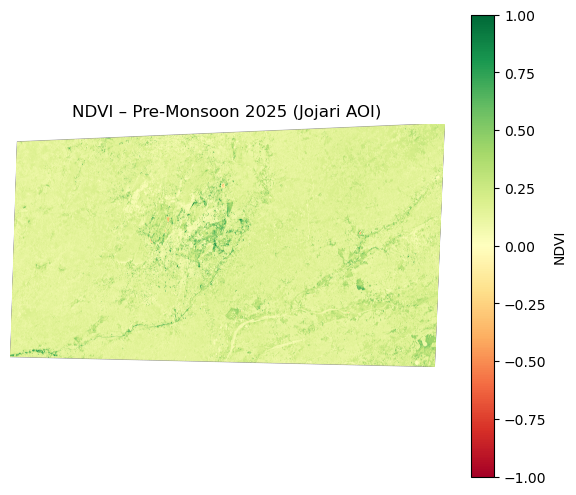

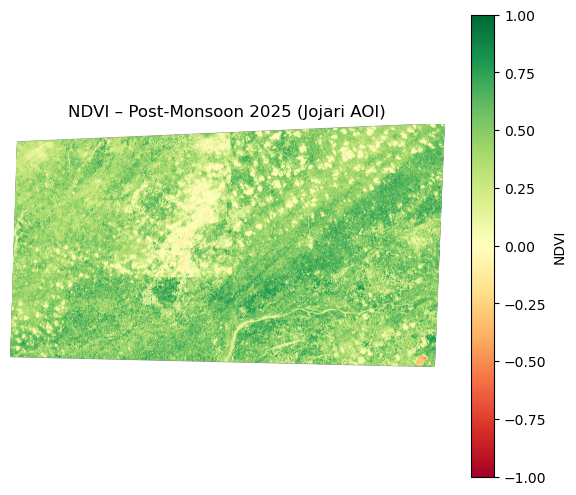

In [70]:
def plot_ndvi(path, title):
    with rasterio.open(path) as src:
        ndvi = src.read(1)
    ndvi = np.ma.masked_invalid(ndvi)

    plt.figure(figsize=(7,6))
    plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
    plt.colorbar(label="NDVI")
    plt.title(title)
    plt.axis("off")
    plt.show()

plot_ndvi("data/results/pre_ndvi_clip.tif",  "NDVI – Pre-Monsoon 2025 (Jojari AOI)")
plot_ndvi("data/results/post_ndvi_clip.tif", "NDVI – Post-Monsoon 2025 (Jojari AOI)")


In [95]:
#Calculate Pre and Post NDWI
import numpy as np
import rasterio

def compute_ndwi(green_path, nir_path, out_path):
    with rasterio.open(green_path) as gsrc, rasterio.open(nir_path) as nsrc:
        green = gsrc.read(1).astype("float32")
        nir   = nsrc.read(1).astype("float32")

        ndwi = np.zeros_like(green, dtype="float32")
        mask = (green + nir) != 0   # avoid divide by zero

        ndwi[mask] = (green[mask] - nir[mask]) / (green[mask] + nir[mask])
        ndwi[~mask] = np.nan

        meta = gsrc.meta.copy()
        meta.update(dtype="float32", nodata=np.nan)

        with rasterio.open(out_path, "w", **meta) as dst:
            dst.write(ndwi, 1)


# Pre-monsoon NDWI
compute_ndwi(
    "data/results/pre_green_3857.tif",
    "data/results/pre_nir_3857.tif",
    "data/results/pre_ndwi_3857.tif"
)

# Post-monsoon NDWI
compute_ndwi(
    "data/results/post_green_3857.tif",
    "data/results/post_nir_3857.tif",
    "data/results/post_ndwi_3857.tif"
)


In [100]:
#Mask NoData + Invalid values properly
import numpy as np
import rasterio

def clean_ndwi(in_path, out_path):
    with rasterio.open(in_path) as src:
        arr = src.read(1).astype("float32")
        nodata = src.nodata

        arr[arr == nodata] = np.nan
        arr[np.isinf(arr)] = np.nan

        meta = src.meta.copy()
        meta.update(nodata=np.nan, dtype="float32")

        with rasterio.open(out_path, "w", **meta) as dst:
            dst.write(arr, 1)

clean_ndwi("data/results/pre_ndwi_3857.tif",  "data/results/pre_ndwi_clean.tif")
clean_ndwi("data/results/post_ndwi_3857.tif", "data/results/post_ndwi_clean.tif")


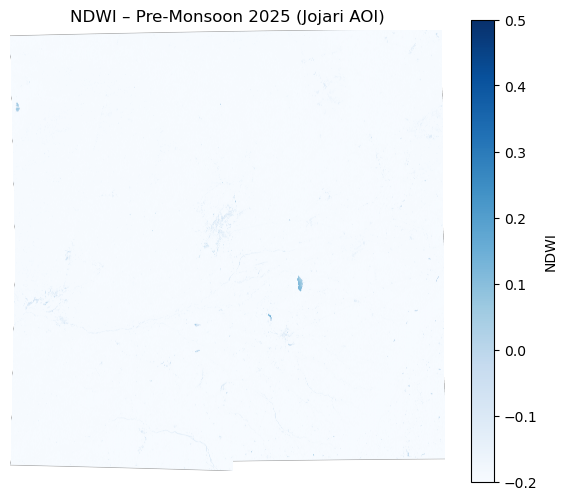

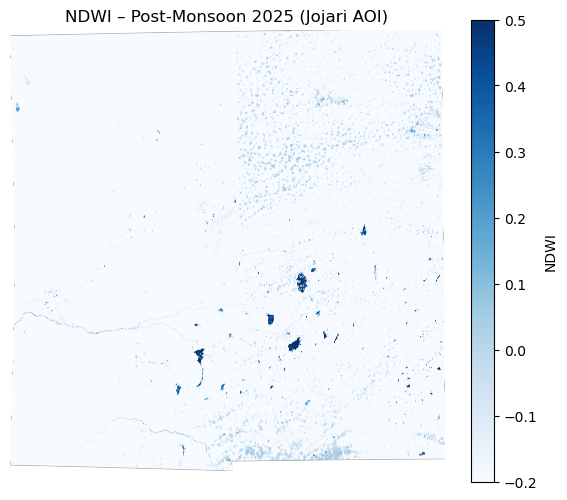

In [1]:
import matplotlib.pyplot as plt
import rasterio
import numpy as np

def plot_ndwi(path, title):
    with rasterio.open(path) as src:
        ndwi = src.read(1)
        ndwi = np.ma.masked_invalid(ndwi)

        plt.figure(figsize=(7,6))
        plt.imshow(ndwi, cmap="Blues", vmin=-0.2, vmax=0.5)
        plt.colorbar(label="NDWI")
        plt.title(title)
        plt.axis("off")
        plt.show()

plot_ndwi("data/results/pre_ndwi_clean.tif",  "NDWI – Pre-Monsoon 2025 (Jojari AOI)")
plot_ndwi("data/results/post_ndwi_clean.tif", "NDWI – Post-Monsoon 2025 (Jojari AOI)")


In [4]:
#aoi for study area clip
aoi_coords = [
    (72.6811, 26.4397),  # 26°26'23"N, 72°40'54"E
    (73.5056, 26.4717),  # 26°28'18"N, 73°30'20"E
    (73.4864, 26.0506),  # 26°03'02"N, 73°29'11"E
    (72.6681, 26.0678)   # 26°04'04"N, 72°40'05"E
]

aoi = gpd.GeoDataFrame(geometry=[Polygon(aoi_coords)], crs="EPSG:4326")

In [5]:
#reproject aoi
aoi_3857 = aoi.to_crs("EPSG:3857")


In [6]:
import numpy as np
import rasterio
from rasterio.mask import mask

# Clip function (works for NDVI / NDWI / any raster)
def clip_raster(in_raster, out_raster, aoi_gdf):
    with rasterio.open(in_raster) as src:
        clipped, transform = mask(src, aoi_gdf.geometry, crop=True)
        meta = src.meta.copy()
        meta.update({
            "height": clipped.shape[1],
            "width": clipped.shape[2],
            "transform": transform,
            "nodata": np.nan,
            "dtype": "float32"
        })

    with rasterio.open(out_raster, "w", **meta) as dst:
        dst.write(clipped)

# Paths for NDWI (your cleaned NDWI rasters are best)
pre_ndwi  = "data/results/pre_ndwi_clean.tif"
post_ndwi = "data/results/post_ndwi_clean.tif"

clip_raster(pre_ndwi,  "data/results/pre_ndwi_clip.tif",  aoi_3857)
clip_raster(post_ndwi, "data/results/post_ndwi_clip.tif", aoi_3857)


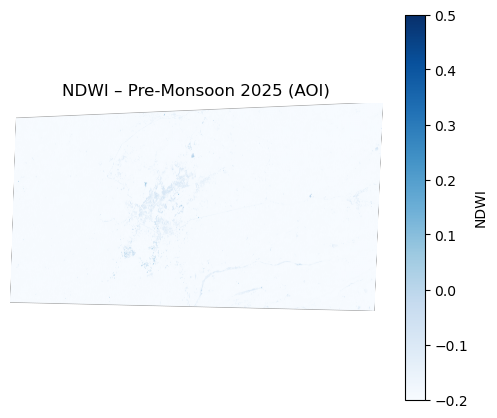

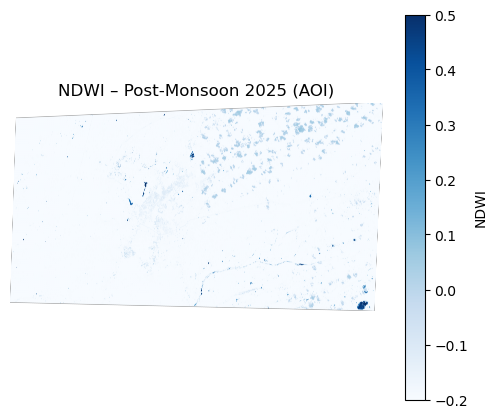

In [7]:
import matplotlib.pyplot as plt
import rasterio
import numpy as np

def plot_ndwi(path, title):
    with rasterio.open(path) as src:
        ndwi = src.read(1)
        ndwi = np.ma.masked_invalid(ndwi)

        plt.figure(figsize=(6,5))
        plt.imshow(ndwi, cmap="Blues", vmin=-0.2, vmax=0.5)
        plt.colorbar(label="NDWI")
        plt.title(title)
        plt.axis("off")
        plt.show()

plot_ndwi("data/results/pre_ndwi_clip.tif",  "NDWI – Pre-Monsoon 2025 (AOI)")
plot_ndwi("data/results/post_ndwi_clip.tif", "NDWI – Post-Monsoon 2025 (AOI)")


In [ ]:
# ==========================
# DAY 3: GEOSERVER PUBLISHING
# ==========================

In [13]:
pip install -U geoserver-restconfig


Note: you may need to restart the kernel to use updated packages.


In [9]:
from geoserver.catalog import Catalog


In [25]:
import os
import requests
from requests.auth import HTTPBasicAuth
from geoserver.catalog import Catalog

# ==========================
# CONFIG
# ==========================
GEOSERVER_URL = "http://localhost:8080/geoserver/rest"
USERNAME = "admin"
PASSWORD = "geoserver"

WORKSPACE = "jojariproject"

RASTERS = {
    "pre_ndvi":  "data/results/pre_ndvi_clip.tif",
    "post_ndvi": "data/results/post_ndvi_clip.tif",
    "pre_ndwi":  "data/results/pre_ndwi_clip.tif",
    "post_ndwi": "data/results/post_ndwi_clip.tif",
}

# ==========================
# CONNECT
# ==========================
cat = Catalog(GEOSERVER_URL, USERNAME, PASSWORD)

# ==========================
# CREATE WORKSPACE
# ==========================
if not cat.get_workspace(WORKSPACE):
    cat.create_workspace(WORKSPACE, WORKSPACE)
    print("✅ Workspace created:", WORKSPACE)
else:
    print("ℹ Workspace exists:", WORKSPACE)

# ==========================
# HELPER: PUBLISH VIA RAW REST
# ==========================
import requests
from requests.auth import HTTPBasicAuth

def publish_coverage_raw(workspace, store, layer_name):
    # Get native coverage name
    url_list = f"http://localhost:8080/geoserver/rest/workspaces/{workspace}/coveragestores/{store}/coverages.json"
    r = requests.get(url_list, auth=HTTPBasicAuth("admin", "geoserver"))
    r.raise_for_status()
    covs = r.json()["coverages"]["coverage"]
    native_name = covs[0]["name"]   # ← this is pre_ndvi_store
    print("🔎 Native coverage name:", native_name)

    # Publish using native name
    url_pub = f"http://localhost:8080/geoserver/rest/workspaces/{workspace}/coveragestores/{store}/coverages"
    headers = {"Content-Type": "application/xml"}
    xml = f"""
    <coverage>
        <name>{layer_name}</name>
        <nativeName>{native_name}</nativeName>
    </coverage>
    """
    r2 = requests.post(url_pub, data=xml.strip(), headers=headers, auth=HTTPBasicAuth("admin", "geoserver"))
    if r2.status_code not in (200, 201):
        print("❌ Publish failed:", r2.status_code, r2.text)
        r2.raise_for_status()
    print("✅ Layer published:", layer_name)

# ==========================
# UPLOAD STORES + PUBLISH LAYERS
# ==========================
for layer_name, raster_path in RASTERS.items():

    if not os.path.exists(raster_path):
        print("❌ File not found:", raster_path)
        continue

    raster_path = os.path.abspath(raster_path)
    store_name = layer_name + "_store"

    # Create store (upload GeoTIFF)
    store = cat.get_store(store_name, WORKSPACE)
    if store is None:
        print("⬆ Uploading:", raster_path)
        store = cat.create_coveragestore(
            name=store_name,
            workspace=WORKSPACE,
            path=raster_path,
            upload_data=True
        )
        print("✅ Store created:", store_name)
    else:
        print("🔄 Store exists:", store_name)

    # Publish layer if missing
    qualified_name = f"{WORKSPACE}:{layer_name}"
    layer = cat.get_layer(qualified_name)

    if layer is None:
        print("📢 Publishing layer:", qualified_name)
        publish_coverage_raw(WORKSPACE, store_name, layer_name)
    else:
        print("♻ Layer already exists:", qualified_name)

print("\n🎉 GeoServer pipeline finished successfully!")

ℹ Workspace exists: jojariproject
🔄 Store exists: pre_ndvi_store
📢 Publishing layer: jojariproject:pre_ndvi
🔎 Native coverage name: pre_ndvi_store
✅ Layer published: pre_ndvi
⬆ Uploading: C:\Users\Lenovo\3D_Geospatial_Dashboard\data\results\post_ndvi_clip.tif
✅ Store created: post_ndvi_store
📢 Publishing layer: jojariproject:post_ndvi
🔎 Native coverage name: post_ndvi_store
✅ Layer published: post_ndvi
⬆ Uploading: C:\Users\Lenovo\3D_Geospatial_Dashboard\data\results\pre_ndwi_clip.tif
✅ Store created: pre_ndwi_store
📢 Publishing layer: jojariproject:pre_ndwi
🔎 Native coverage name: pre_ndwi_store
✅ Layer published: pre_ndwi
⬆ Uploading: C:\Users\Lenovo\3D_Geospatial_Dashboard\data\results\post_ndwi_clip.tif
✅ Store created: post_ndwi_store
📢 Publishing layer: jojariproject:post_ndwi
🔎 Native coverage name: post_ndwi_store
✅ Layer published: post_ndwi

🎉 GeoServer pipeline finished successfully!
